Notebbok para el entramiento del modelo.

In [116]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Lasso
import joblib


In [117]:
df = pd.read_csv('../data/processed/df_clean.csv')

In [118]:
numerical_cols = [
    'Freedom',  
    'Trust (Government Corruption)', 
    'Family', 
    'Economy (GDP per Capita)',
    'Health (Life Expectancy)',
]

categorical_cols_encoded = [col for col in df.columns if col.startswith('Region_') or col.startswith('Year_')]
target_col = 'Happiness Score'

# Incluir tanto columnas numéricas como categóricas codificadas en X
X = df[numerical_cols + categorical_cols_encoded]
y = df[target_col]


# Dividir en entrenamiento y prueba (70-30)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar solo las columnas numéricas
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

# Convertir a DataFrame para mantener los nombres de las columnas
X_train_num_df = pd.DataFrame(X_train_num, columns=numerical_cols, index=X_train.index)
X_test_num_df = pd.DataFrame(X_test_num, columns=numerical_cols, index=X_test.index)

# Seleccionar columnas categóricas codificadas (ya son 0/1, no necesitan transformación)
X_train_cat_df = X_train[categorical_cols_encoded]
X_test_cat_df = X_test[categorical_cols_encoded]

# Combinar columnas numéricas escaladas y categóricas codificadas
X_train_encoded = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_num_df, X_test_cat_df], axis=1)


In [119]:
#Radom Forest Regressor
model_RFR = RandomForestRegressor(random_state=42)
model_RFR.fit(X_train_encoded, y_train)
y_pred_RFR = model_RFR.predict(X_test_encoded)
mse_RFR = mean_squared_error(y_test, y_pred_RFR)
r2_RFR = r2_score(y_test, y_pred_RFR)
mae_RFR = mean_absolute_error(y_test, y_pred_RFR)
print("Radom Forest Regressor - Metricas")
print(f"\nMean Squared Error: {mse_RFR}")
print(f"R2 Score: {r2_RFR}")
print(f"Mean Absolute Error: {mae_RFR}")

Radom Forest Regressor - Metricas

Mean Squared Error: 0.18658216645987252
R2 Score: 0.8503200704469764
Mean Absolute Error: 0.3117723566878978


In [120]:
# XGBoost
model_XGB = XGBRegressor(random_state=42)
model_XGB.fit(X_train_encoded, y_train)
y_pred_XGB = model_XGB.predict(X_test_encoded)
mse_XGB = mean_squared_error(y_test, y_pred_XGB)
r2_XGB = r2_score(y_test, y_pred_XGB)
mae_XGB = mean_absolute_error(y_test, y_pred_XGB)
print("XCGBoost - Metricas:")
print(f"\nXGBoost Mean Squared Error (MSE): {mse_XGB:.4f}")
print(f"XGBoost R² Score: {r2_XGB:.4f}")
print(f"XGBoost Mean Absolute Error (MAE): {mae_XGB:.4f}")

XCGBoost - Metricas:

XGBoost Mean Squared Error (MSE): 0.1587
XGBoost R² Score: 0.8727
XGBoost Mean Absolute Error (MAE): 0.2604


In [121]:
#Support Vector Regressor
model_SVR = SVR(kernel = "rbf")
model_SVR.fit(X_train_encoded, y_train)
y_pred_SVR = model_SVR.predict(X_test_encoded)
mse_SVR = mean_squared_error(y_test, y_pred_SVR)
r2_SVR = r2_score(y_test, y_pred_SVR)
mae_SVR = mean_absolute_error(y_test, y_pred_SVR)
print("\nSupport Vector Regressor - Métricas:")
print(f"\nSupport Vector Regressor - MSE: {mse_SVR:.4f}")
print(f"Support Vector Regressor - R²: {r2_SVR:.4f}")
print(f"Support Vector Regressor - MAE: {mae_SVR:.4f}")


Support Vector Regressor - Métricas:

Support Vector Regressor - MSE: 0.2305
Support Vector Regressor - R²: 0.8151
Support Vector Regressor - MAE: 0.3566


In [122]:
#k-Nearest Neighbors regressor
model_KNN = KNeighborsRegressor(n_neighbors=5)
model_KNN.fit(X_train_encoded, y_train)
y_pred_KNN = model_KNN.predict(X_test_encoded)
mse_KNN = mean_squared_error(y_test, y_pred_KNN)
r2_KNN = r2_score(y_test, y_pred_KNN)
mae_KNN = mean_absolute_error(y_test, y_pred_KNN)
print("\nk-Nearest Neighbors Regressor - Métricas:")
print(f"\nk-Nearest Neighbors Regressor - MSE: {mse_KNN:.4f}")
print(f"k-Nearest Neighbors Regressor - R²: {r2_KNN:.4f}")
print(f"k-Nearest Neighbors Regressor - MAE: {mae_KNN:.4f}")


k-Nearest Neighbors Regressor - Métricas:

k-Nearest Neighbors Regressor - MSE: 0.2681
k-Nearest Neighbors Regressor - R²: 0.7850
k-Nearest Neighbors Regressor - MAE: 0.3846


In [123]:
# Lasso regression
model_Lasso = Lasso(alpha=0.1, random_state=42)
model_Lasso.fit(X_train_encoded, y_train)
y_pred_Lasso = model_Lasso.predict(X_test_encoded)
mse_Lasso = mean_squared_error(y_test, y_pred_Lasso)
r2_Lasso = r2_score(y_test, y_pred_Lasso)
mae_Lasso = mean_absolute_error(y_test, y_pred_Lasso)
print("\nLasso Regression - Métricas:")
print(f"\nLasso Regression - MSE: {mse_Lasso:.4f}")
print(f"Lasso Regression - R²: {r2_Lasso:.4f}")
print(f"Lasso Regression - MAE: {mae_Lasso:.4f}")


Lasso Regression - Métricas:

Lasso Regression - MSE: 0.3525
Lasso Regression - R²: 0.7172
Lasso Regression - MAE: 0.4621


In [124]:
# GR
model_GR = GradientBoostingRegressor(random_state=42)
model_GR.fit(X_train_encoded, y_train)
y_pred_GR = model_GR.predict(X_test_encoded)
mse_GR = mean_squared_error(y_test, y_pred_GR)
r2_GR = r2_score(y_test, y_pred_GR)
mae_GR = mean_absolute_error(y_test, y_pred_GR)
print("\nGradient Boosting Regressor - Métricas:")
print(f"\nGradient Boosting Regressor - MSE: {mse_GR:.4f}")
print(f"Gradient Boosting Regressor - R²: {r2_GR:.4f}")
print(f"Gradient Boosting Regressor - MAE: {mae_GR:.4f}")


Gradient Boosting Regressor - Métricas:

Gradient Boosting Regressor - MSE: 0.2235
Gradient Boosting Regressor - R²: 0.8207
Gradient Boosting Regressor - MAE: 0.3525


In [125]:
# RMSE
model_RMSE = LinearRegression()
model_RMSE.fit(X_train_encoded, y_train)
y_pred_RMSE = model_RMSE.predict(X_test_encoded)
mse_RMSE = mean_squared_error(y_test, y_pred_RMSE)
r2_RMSE = r2_score(y_test, y_pred_RMSE)
mae_RMSE = mean_absolute_error(y_test, y_pred_RMSE)
print("\nLinear Regression - Métricas:")
print(f"\nLinear Regression - MSE: {mse_RMSE:.4f}")
print(f"Linear Regression - R²: {r2_RMSE:.4f}")
print(f"Linear Regression - MAE: {mae_RMSE:.4f}")


Linear Regression - Métricas:

Linear Regression - MSE: 0.2849
Linear Regression - R²: 0.7714
Linear Regression - MAE: 0.4017



Importancia de características:
                                   Feature  Importance
13      Region_Latin America and Caribbean    0.360169
3                 Economy (GDP per Capita)    0.194379
12                     Region_Eastern Asia    0.139286
4                 Health (Life Expectancy)    0.076546
11       Region_Central and Eastern Europe    0.043716
18               Region_Sub-Saharan Africa    0.029451
0                                  Freedom    0.025820
17                    Region_Southern Asia    0.025167
14  Region_Middle East and Northern Africa    0.023461
16                Region_Southeastern Asia    0.018441
2                                   Family    0.016666
1            Trust (Government Corruption)    0.014308
19                   Region_Western Europe    0.012189
9                                Year_2019    0.009717
5                                Year_2015    0.004173
8                                Year_2018    0.002644
15                    Region_Nor

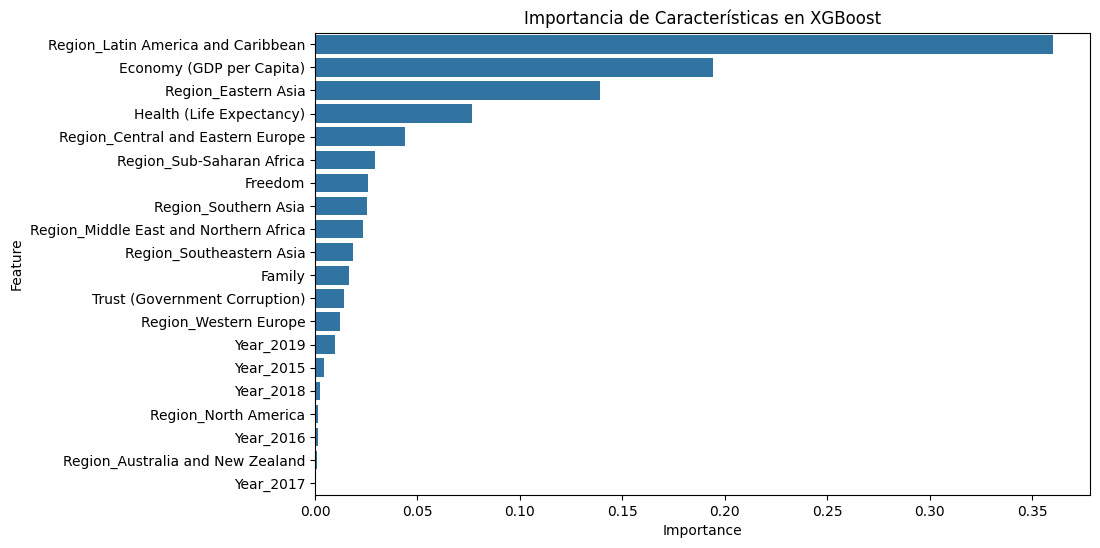

In [ ]:
# Importancia de características
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_XGB.feature_importances_
})
print("\nImportancia de características:")
print(feature_importance.sort_values(by='Importance', ascending=False))

()

In [ ]:
# Visualizar importancia
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.sort_values(by='Importance', ascending=False))
plt.title('Importancia de Características en XGBoost')
plt.show

Resumen
Más importantes: Region_Latin America and Caribbean, Economy, Region_Eastern Asia, Health.
Moderadamente importantes: Otras regiones (Central and Eastern Europe, Sub-Saharan Africa).
Menos importantes: Freedom, Family, Trust, Year_, Region_Western Europe, Region_North America.
Implicación: Year_ y algunas regiones (e.g., Australia and New Zealand) podrían excluirse para simplificar el modelo sin perder mucho R².

XGBoost - Métricas:
XGBoost Mean Squared Error (MSE): 0.2050
XGBoost R² Score: 0.8356
XGBoost Mean Absolute Error (MAE): 0.3458

Importancia de características:
                                   Feature  Importance
3                 Economy (GDP per Capita)    0.328851
7       Region_Latin America and Caribbean    0.240332
12               Region_Sub-Saharan Africa    0.163719
6                      Region_Eastern Asia    0.059337
5        Region_Central and Eastern Europe    0.053520
0                                  Freedom    0.051292
2                                   Family    0.040059
1            Trust (Government Corruption)    0.016000
8   Region_Middle East and Northern Africa    0.015918
11                    Region_Southern Asia    0.013650
10                Region_Southeastern Asia    0.006413
13                   Region_Western Europe    0.006293
9                     Region_North America    0.004008
4         Region_Australia and New Zealand    0.000608


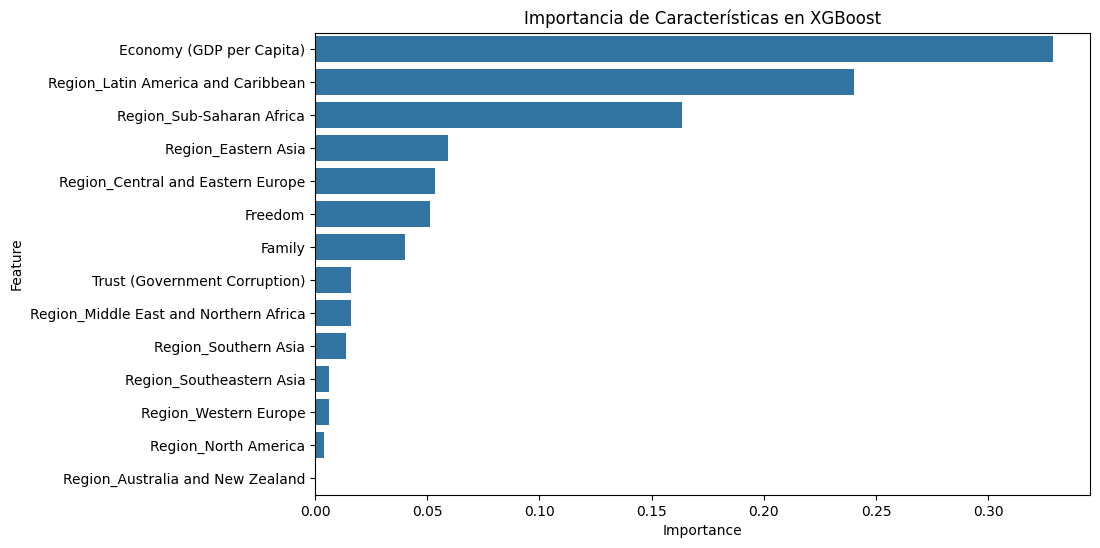

In [130]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Supongamos que df es tu dataset unificado
# Asumimos que ya codificaste Region y Year con pd.get_dummies
# df = pd.get_dummies(df_unido, columns=['Region', 'Year'], drop_first=True)

# Definir columnas
numerical_cols = [
    'Freedom',
    'Trust (Government Corruption)',
    'Family',
    'Economy (GDP per Capita)',
]
categorical_cols_encoded = [col for col in df.columns if col.startswith('Region_')]
target_col = 'Happiness Score'

# Incluir columnas numéricas y categóricas codificadas en X
X = df[numerical_cols + categorical_cols_encoded]
y = df[target_col]

# Dividir en entrenamiento y prueba (80-20, como en tu código)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar solo las columnas numéricas
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numerical_cols])
X_test_num = scaler.transform(X_test[numerical_cols])

# Convertir a DataFrame
X_train_num_df = pd.DataFrame(X_train_num, columns=numerical_cols, index=X_train.index)
X_test_num_df = pd.DataFrame(X_test_num, columns=numerical_cols, index=X_test.index)

# Seleccionar columnas categóricas codificadas
X_train_cat_df = X_train[categorical_cols_encoded]
X_test_cat_df = X_test[categorical_cols_encoded]

# Combinar columnas numéricas escaladas y categóricas codificadas
X_train_encoded = pd.concat([X_train_num_df, X_train_cat_df], axis=1)
X_test_encoded = pd.concat([X_test_num_df, X_test_cat_df], axis=1)

# XGBoost
model_XGB = XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1, max_depth=3)
model_XGB.fit(X_train_encoded, y_train)
y_pred_XGB = model_XGB.predict(X_test_encoded)

# Métricas
mse_XGB = mean_squared_error(y_test, y_pred_XGB)
r2_XGB = r2_score(y_test, y_pred_XGB)
mae_XGB = mean_absolute_error(y_test, y_pred_XGB)
print("XGBoost - Métricas:")
print(f"XGBoost Mean Squared Error (MSE): {mse_XGB:.4f}")
print(f"XGBoost R² Score: {r2_XGB:.4f}")
print(f"XGBoost Mean Absolute Error (MAE): {mae_XGB:.4f}")

# Importancia de características (corregido)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model_XGB.feature_importances_
})
print("\nImportancia de características:")
print(feature_importance.sort_values(by='Importance', ascending=False))

# Visualizar importancia
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.sort_values(by='Importance', ascending=False))
plt.title('Importancia de Características en XGBoost')
plt.show()

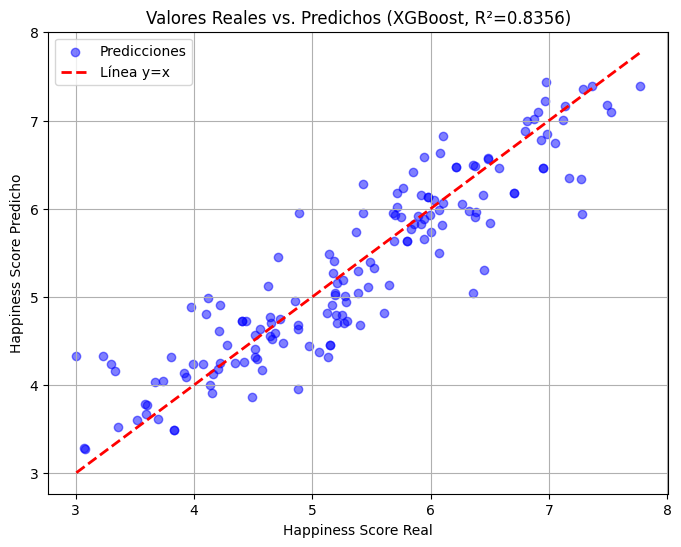

In [134]:
# Gráfica de dispersión: Valores reales vs. predichos
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_XGB, color='blue', alpha=0.5, label='Predicciones')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea y=x')
plt.xlabel('Happiness Score Real')
plt.ylabel('Happiness Score Predicho')
plt.title('Valores Reales vs. Predichos (XGBoost, R²={:.4f})'.format(r2_XGB))
plt.legend()
plt.grid(True)
plt.show()

In [131]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid_search.fit(X_train_encoded, y_train)
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor R² (CV):", grid_search.best_score_)

# Evaluar en test
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test_encoded)
print("\nMétricas del mejor modelo:")
print(f"MSE: {mean_squared_error(y_test, y_pred):.4f}")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.4f}")

Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 300}
Mejor R² (CV): 0.8807632593990155

Métricas del mejor modelo:
MSE: 0.1459
R²: 0.8829
MAE: 0.2695


#Guardar el modelo deseado 

In [ ]:

joblib.dump(model_XGB,'../models/happiness_model_XGB.pkl')  

['../models/happiness_model_XGB.pkl']